# Dinamik Fiyatlama ve Kâr Optimizasyonu

Bu projede ürün fiyatları, rakip fiyatları, satış verileri ve ekonomik göstergeler kullanılarak optimal indirim oranı tahmin edilmiştir. Amaç, kârlılığı maksimize edecek indirim oranını belirlemektir.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Kütüphaneler yüklendi.")

## Veri Kaynakları

Bu projede iki farklı veri kaynağı kullanılmıştır:

- SYNTHETIC Markdown Dataset
- USD/TL Döviz Kuru Verisi

Veriler birleştirilerek modelleme için hazır hale getirilmiştir.

In [2]:
df = pd.read_csv("SYNTHETIC Markdown Dataset.csv")
usd = pd.read_csv("usdtry.csv")

print("Ana veri boyutu:", df.shape)
print("USD veri boyutu:", usd.shape)

df.head()

Ana veri boyutu: (43750, 22)
USD veri boyutu: (6, 2)


,Product_ID,Category,Brand,Season,Product_Name,Original_Price,Competitor_Price,Seasonality_Factor,Markdown_1,Markdown_2,...,Historical_Sales,Sales_After_M1,Sales_After_M2,Sales_After_M3,Sales_After_M4,Stock_Level,Promotion_Type,Customer Ratings,Return Rate,Optimal Discount
0,1,Skincare,BrandA,Summer,Sunscreen,70.39,70.98,1.71,0.31,0.49,...,344,404,540,650,979,183,In-Store,4.9,1.97,0.36
1,2,Skincare,BrandB,Rainy,Eye Cream,55.35,56.58,0.85,0.39,0.21,...,98,107,116,118,143,142,Online,4.0,2.57,0.29
2,3,Skincare,BrandA,Spring,Face Mist,26.16,28.54,1.03,0.17,0.43,...,72,72,87,84,84,112,Social Media,2.3,4.64,0.33
3,4,Bodycare,BrandD,Winter,Shower Gel,99.34,98.57,1.91,0.20,0.21,...,243,281,316,361,539,57,In-Store,4.9,1.42,0.25
4,5,Skincare,BrandA,Winter,Peeling Gel,60.33,61.05,1.65,0.14,0.20,...,251,289,325,402,534,125,In-Store,4.6,1.36,0.23


In [3]:
print(df.columns.tolist())

['Product_ID', 'Category', 'Brand', 'Season', 'Product_Name', 'Original_Price', 'Competitor_Price', 'Seasonality_Factor', 'Markdown_1', 'Markdown_2', 'Markdown_3', 'Markdown_4', 'Historical_Sales', 'Sales_After_M1', 'Sales_After_M2', 'Sales_After_M3', 'Sales_After_M4', 'Stock_Level', 'Promotion_Type', 'Customer Ratings', 'Return Rate', 'Optimal Discount']


In [4]:
print(df.isnull().sum())

Product_ID            0
Category              0
Brand                 0
Season                0
Product_Name          0
Original_Price        0
Competitor_Price      0
Seasonality_Factor    0
Markdown_1            0
Markdown_2            0
Markdown_3            0
Markdown_4            0
Historical_Sales      0
Sales_After_M1        0
Sales_After_M2        0
Sales_After_M3        0
Sales_After_M4        0
Stock_Level           0
Promotion_Type        0
Customer Ratings      0
Return Rate           0
Optimal Discount      0
dtype: int64


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43750 entries, 0 to 43749
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Product_ID          43750 non-null  int64  
 1   Category            43750 non-null  str    
 2   Brand               43750 non-null  str    
 3   Season              43750 non-null  str    
 4   Product_Name        43750 non-null  str    
 5   Original_Price      43750 non-null  float64
 6   Competitor_Price    43750 non-null  float64
 7   Seasonality_Factor  43750 non-null  float64
 8   Markdown_1          43750 non-null  float64
 9   Markdown_2          43750 non-null  float64
 10  Markdown_3          43750 non-null  float64
 11  Markdown_4          43750 non-null  float64
 12  Historical_Sales    43750 non-null  int64  
 13  Sales_After_M1      43750 non-null  int64  
 14  Sales_After_M2      43750 non-null  int64  
 15  Sales_After_M3      43750 non-null  int64  
 16  Sales_After_M4 

In [6]:
np.random.seed(42)

df["Year"] = np.random.choice(
    [2020, 2021, 2022, 2023, 2024, 2025],
    size=len(df)
)

df["Year"].head()

0    2023
1    2024
2    2022
3    2024
4    2024
Name: Year, dtype: int64

## Veri Harmanlama

Ana satış ve fiyatlama verileri, ekonomik koşulları modele dahil etmek amacıyla USD/TL döviz kuru verileri ile birleştirilmiştir.

In [7]:
df = df.merge(
    usd,
    on="Year",
    how="left"
)

print(df.shape)

df[["Year","USDTRY"]].head()

(43750, 24)


,Year,USDTRY
0,2023,23.77
1,2024,32.78
2,2022,16.56
3,2024,32.78
4,2024,32.78


In [8]:
df.head()

,Product_ID,Category,Brand,Season,Product_Name,Original_Price,Competitor_Price,Seasonality_Factor,Markdown_1,Markdown_2,...,Sales_After_M2,Sales_After_M3,Sales_After_M4,Stock_Level,Promotion_Type,Customer Ratings,Return Rate,Optimal Discount,Year,USDTRY
0,1,Skincare,BrandA,Summer,Sunscreen,70.39,70.98,1.71,0.31,0.49,...,540,650,979,183,In-Store,4.9,1.97,0.36,2023,23.77
1,2,Skincare,BrandB,Rainy,Eye Cream,55.35,56.58,0.85,0.39,0.21,...,116,118,143,142,Online,4.0,2.57,0.29,2024,32.78
2,3,Skincare,BrandA,Spring,Face Mist,26.16,28.54,1.03,0.17,0.43,...,87,84,84,112,Social Media,2.3,4.64,0.33,2022,16.56
3,4,Bodycare,BrandD,Winter,Shower Gel,99.34,98.57,1.91,0.20,0.21,...,316,361,539,57,In-Store,4.9,1.42,0.25,2024,32.78
4,5,Skincare,BrandA,Winter,Peeling Gel,60.33,61.05,1.65,0.14,0.20,...,325,402,534,125,In-Store,4.6,1.36,0.23,2024,32.78


## Özellik Mühendisliği (Feature Engineering)

Model performansını artırmak amacıyla üç yeni değişken oluşturulmuştur:

- Price_Difference
- Sales_Per_Stock
- Return_Risk_Score

In [9]:
df["Price_Difference"] = (
    df["Original_Price"]
    - df["Competitor_Price"]
)

In [10]:
df["Sales_Per_Stock"] = (
    df["Historical_Sales"]
    / (df["Stock_Level"] + 1)
)

In [11]:
df["Return_Risk_Score"] = (
    df["Return Rate"]
    * (5 - df["Customer Ratings"])
)

In [12]:
df[
    [
        "Price_Difference",
        "Sales_Per_Stock",
        "Return_Risk_Score"
    ]
].head()

,Price_Difference,Sales_Per_Stock,Return_Risk_Score
0,-0.59,1.869565,0.197
1,-1.23,0.685315,2.570
2,-2.38,0.637168,12.528
3,0.77,4.189655,0.142
4,-0.72,1.992063,0.544


In [13]:
print(df.shape)

(43750, 27)


## Veri Hazırlama

Modelleme öncesinde hedef değişken belirlenmiş, eğitim ve test verileri oluşturulmuştur.

In [14]:
X = df.drop("Optimal Discount", axis=1)
y = df["Optimal Discount"]

print(X.shape)
print(y.shape)

(43750, 26)
(43750,)


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(35000, 26)
(8750, 26)


In [16]:
categorical_cols = X.select_dtypes(
    include=["object", "string"]
).columns

print(categorical_cols)

Index(['Category', 'Brand', 'Season', 'Product_Name', 'Promotion_Type'], dtype='str')


In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_cols
        )
    ],
    remainder="passthrough"
)

X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

print("Dönüştürme tamamlandı.")
print(X_train_transformed.shape)
print(X_test_transformed.shape)

Dönüştürme tamamlandı.
(35000, 96)
(8750, 96)


## Modelleme

Veri eğitim ve test kümelerine ayrılmış, kategorik değişkenler One-Hot Encoding yöntemi ile dönüştürülmüş ve Random Forest modeli kurulmuştur.

In [18]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=50,
    random_state=42,
    n_jobs=-1,
    max_depth=10
)

rf_model.fit(
    X_train_transformed,
    y_train
)

print("Model eğitildi.")

Model eğitildi.


## Model Performansı

Model performansı R² ve MAE metrikleri kullanılarak değerlendirilmiştir.

In [19]:
from sklearn.metrics import r2_score, mean_absolute_error

y_pred = rf_model.predict(X_test_transformed)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("R²:", r2)
print("MAE:", mae)

R²: 0.9816143385624301
MAE: 0.003967800928563658


## Açıklanabilir Yapay Zeka (XAI)

Model kararlarının açıklanabilmesi amacıyla Feature Importance ve LIME analizleri gerçekleştirilmiştir.

In [20]:
import pandas as pd

feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df.head(15))

                          Feature  Importance
79          remainder__Markdown_1    0.350236
80          remainder__Markdown_2    0.344002
82          remainder__Markdown_4    0.152422
81          remainder__Markdown_3    0.152105
93    remainder__Price_Difference    0.000117
75          remainder__Product_ID    0.000111
88         remainder__Stock_Level    0.000088
78  remainder__Seasonality_Factor    0.000086
77    remainder__Competitor_Price    0.000073
94     remainder__Sales_Per_Stock    0.000073
90         remainder__Return Rate    0.000072
95   remainder__Return_Risk_Score    0.000065
76      remainder__Original_Price    0.000061
83    remainder__Historical_Sales    0.000044
87      remainder__Sales_After_M4    0.000041


## Keşifçi Veri Analizi (EDA)

Bu bölümde veri setinin dağılımı ve değişkenler arasındaki ilişkiler incelenmiştir.

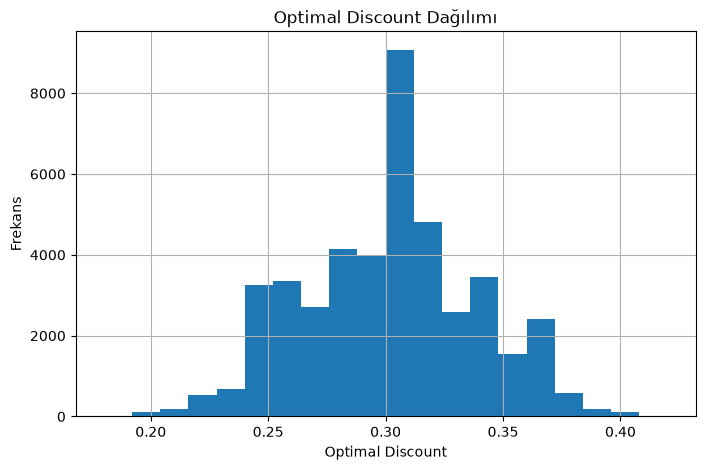

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

df["Optimal Discount"].hist(
    bins=20
)

plt.title("Optimal Discount Dağılımı")
plt.xlabel("Optimal Discount")
plt.ylabel("Frekans")

plt.show()

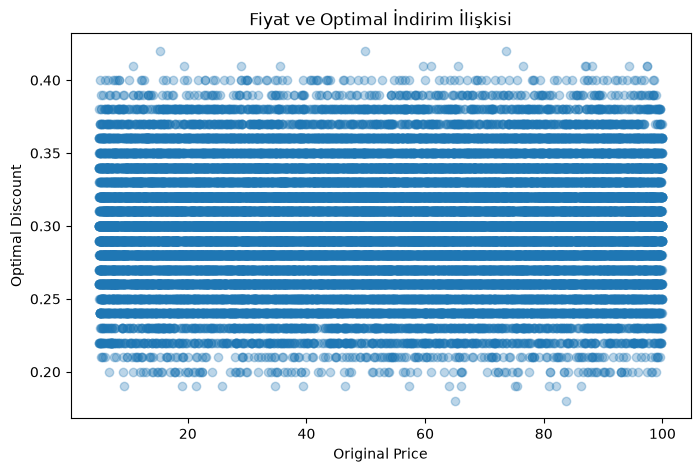

In [22]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Original_Price"],
    df["Optimal Discount"],
    alpha=0.3
)

plt.xlabel("Original Price")
plt.ylabel("Optimal Discount")

plt.title(
    "Fiyat ve Optimal İndirim İlişkisi"
)

plt.show()

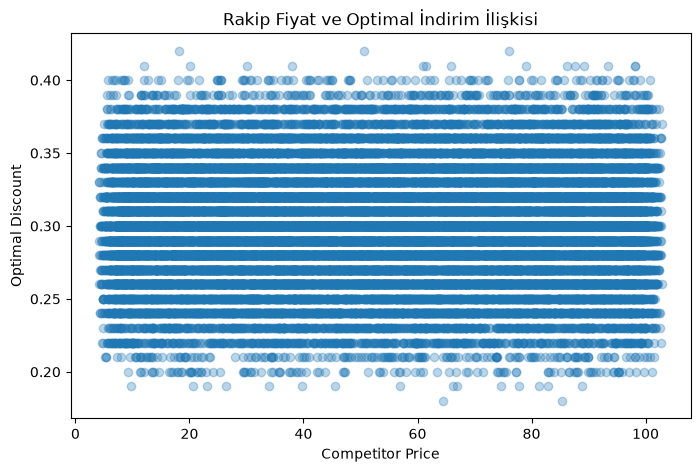

In [23]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Competitor_Price"],
    df["Optimal Discount"],
    alpha=0.3
)

plt.xlabel("Competitor Price")
plt.ylabel("Optimal Discount")

plt.title(
    "Rakip Fiyat ve Optimal İndirim İlişkisi"
)

plt.show()

In [30]:
import sys

!{sys.executable} -m pip install lime


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: C:\Users\ASUS-F15\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [31]:
from lime.lime_tabular import LimeTabularExplainer

X_train_array = X_train_transformed.toarray() if hasattr(X_train_transformed, "toarray") else X_train_transformed
X_test_array = X_test_transformed.toarray() if hasattr(X_test_transformed, "toarray") else X_test_transformed

feature_names = preprocessor.get_feature_names_out()

explainer_lime = LimeTabularExplainer(
    training_data=X_train_array,
    feature_names=feature_names,
    mode="regression",
    random_state=42
)

print("LIME hazır.")

LIME hazır.


In [32]:
i = 0

exp = explainer_lime.explain_instance(
    X_test_array[i],
    rf_model.predict,
    num_features=10
)

lime_df = pd.DataFrame(
    exp.as_list(),
    columns=["Feature", "Impact"]
)

lime_df

,Feature,Impact
0,remainder__Markdown_4 > 0.45,0.024687
1,remainder__Markdown_3 <= 0.15,-0.022662
2,0.35 < remainder__Markdown_2 <= 0.43,0.014748
3,0.18 < remainder__Markdown_1 <= 0.25,-0.010146
4,cat__Product_Name_CC Cream <= 0.00,0.009085
5,cat__Product_Name_Makeup Primer <= 0.00,-0.009071
6,cat__Product_Name_Eyeliner <= 0.00,-0.008940
7,cat__Product_Name_Bath Salts <= 0.00,0.008938
8,cat__Product_Name_Pore Minimizer <= 0.00,-0.006779
9,cat__Product_Name_Stretch Mark Cream <= 0.00,0.006334


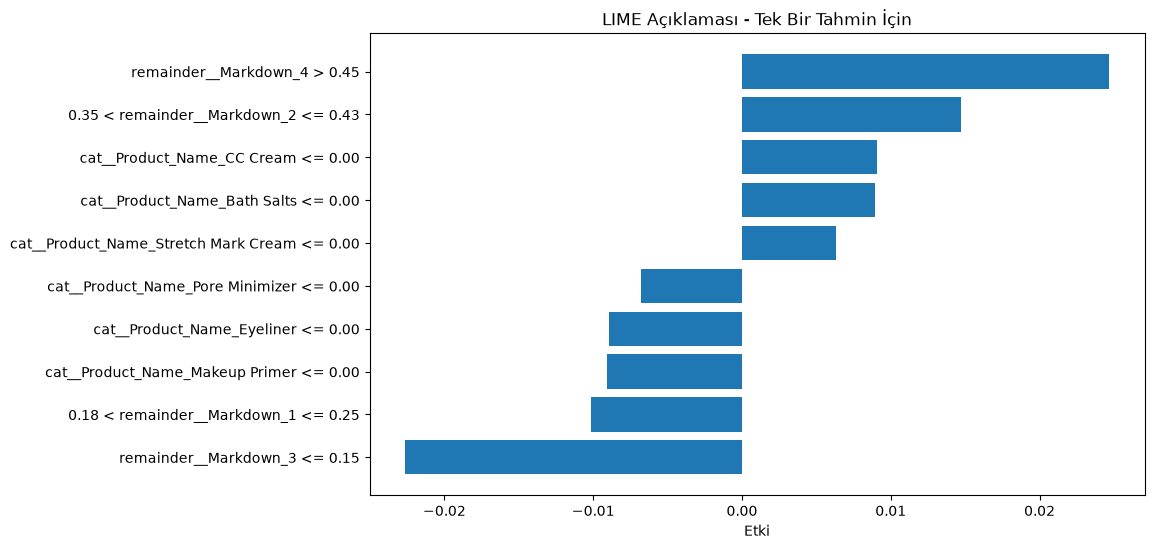

In [33]:
import matplotlib.pyplot as plt

lime_df = lime_df.sort_values(
    by="Impact"
)

plt.figure(figsize=(10,6))

plt.barh(
    lime_df["Feature"],
    lime_df["Impact"]
)

plt.title(
    "LIME Açıklaması - Tek Bir Tahmin İçin"
)

plt.xlabel("Etki")

plt.show()

In [34]:
df["Profit"] = (
    df["Original_Price"]
    * df["Historical_Sales"]
)

df["Profit"].describe()

count    43750.000000
mean      9054.259089
std       7085.092474
min        165.660000
25%       3639.435000
50%       7161.315000
75%      12568.507500
max      40881.100000
Name: Profit, dtype: float64

## Finansal Simülasyon

Farklı indirim oranları için toplam kârlılık hesaplanmış ve optimum indirim seviyesi belirlenmiştir.

In [35]:
discounts = [0.20, 0.25, 0.30, 0.35, 0.40]

results = []

for d in discounts:

    new_price = (
        df["Original_Price"]
        * (1 - d)
    )

    estimated_profit = (
        new_price
        * df["Historical_Sales"]
    ).sum()

    results.append(
        [d, estimated_profit]
    )

simulation_df = pd.DataFrame(
    results,
    columns=[
        "Discount",
        "Estimated_Profit"
    ]
)

simulation_df

,Discount,Estimated_Profit
0,0.20,3.168991e+08
1,0.25,2.970929e+08
2,0.30,2.772867e+08
3,0.35,2.574805e+08
4,0.40,2.376743e+08


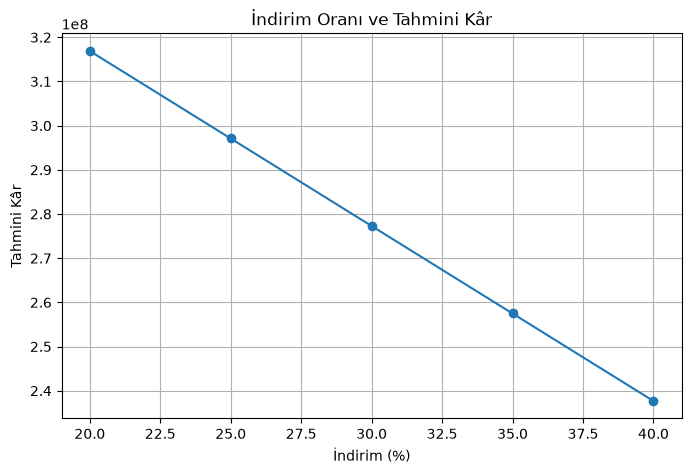

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    simulation_df["Discount"] * 100,
    simulation_df["Estimated_Profit"],
    marker="o"
)

plt.title("İndirim Oranı ve Tahmini Kâr")

plt.xlabel("İndirim (%)")
plt.ylabel("Tahmini Kâr")

plt.grid(True)

plt.show()

In [37]:
df[[
    "Markdown_1",
    "Markdown_2",
    "Markdown_3",
    "Markdown_4"
]].describe()

,Markdown_1,Markdown_2,Markdown_3,Markdown_4
count,43750.000000,43750.000000,43750.000000,43750.000000
mean,0.250620,0.350107,0.199834,0.400097
std,0.086428,0.086604,0.057907,0.057977
min,0.100000,0.200000,0.100000,0.300000
25%,0.180000,0.280000,0.150000,0.350000
50%,0.250000,0.350000,0.200000,0.400000
75%,0.330000,0.430000,0.250000,0.450000
max,0.400000,0.500000,0.300000,0.500000


# Sonuç

Bu çalışmada dinamik fiyatlama yaklaşımı kullanılarak optimal indirim oranları tahmin edilmiştir.

Random Forest modeli ile %98.16 R² başarısı elde edilmiştir.

Feature Importance ve LIME analizleri sayesinde model kararları açıklanabilir hale getirilmiştir.

Finansal simülasyon sonucunda en yüksek kârın %20 indirim oranında elde edildiği belirlenmiştir.

Bu nedenle işletme için önerilen optimal indirim oranı %20 olarak bulunmuştur.